# Test neuromodes eigenstrapping vs original eigenstrapping

This notebook compares the `nulls.eigenstrap` implementation against the original `eigenstrapping.SurfaceEigenstrapping` class to verify correctness. The original implementation can be found [here](https://github.com/nikitas-k/eigenstrapping).

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from importlib.resources import files
from pathlib import Path
from packaging import version

from neuromodes import EigenSolver
from neuromodes.nulls import eigenstrap
from neuromodes.io import fetch_example_surf, fetch_example_map
from neuromodes.mesh import unmask_data
from nsbutils.plotting import plot_surf

In [2]:
res = '4k'
hemi = 'L'

structure = 'midthickness'
mesh, medmask = fetch_example_surf(structure=structure, res=res, hemi='L')
mesh_file = files('neuromodes.data') / f'sp-human_tpl-fsLR_den-{res}_hemi-{hemi}_{structure}.surf.gii'

map = fetch_example_map('myelinmap', res=res)[medmask]
map = (map - np.mean(map)) # to match original implementation which doesn't use the constant mode

In [3]:
n_modes = 10**2 # first 10 eigengroups
n_nulls = 100
seed = 365

We start by computing the eigenmodes and eigenvalues to use for both implementations.

In [4]:
solver = EigenSolver(mesh, mask=medmask).solve(n_modes, set_emode1=True)
evals = solver.evals
emodes = solver.emodes

We can then compute nulls using the original `eigenstrapping.SurfaceEigenstrapping` class. This package is a bit unstable so we just load pre-computed nulls using the original implementation for now. Should the user want to generate the nulls themself they must set `load_precomputed=False`.

Note that the original implementation must be run with a particular configuration to ensure reproducibility/compatibility:

- Set the global seed before running ``SurfaceEigenstrapping(...)`` (e.g., ``np.random.seed(seed)``).
- Additionally, pass this seed into the function call: ``SurfaceEigenstrapping(..., seed=seed)``
- Remember to remove the first eigenmode/eigenvalue from the call to ``SurfaceEigenstrapping``

In [5]:
load_precomputed = True # Set to False to run original code

if load_precomputed:
    # Load precomputed nulls using original implementation

    # `scipy.stats.special_ortho_group.rvs` was updated in scipy=1.16.0 such that it generates different 
    # rotation matrices compared to older versions and thus different nulls. We have computed nulls for 
    # both versions and load the appropriate ones based on the scipy version. 
    import scipy
    if version.parse(scipy.__version__) < version.parse('1.16.0'):
        scipy_version = '1.15.3'
    else:
        scipy_version = '1.16.0'
    print(f"Loading original nulls for scipy version: {scipy_version}")

    test_data_dir = Path.cwd().parent.parent / "tests/test_data"
    nulls_file = f"sp-human_tpl-fsLR_den-{res}_hemi-{hemi}_midthickness_eigenstrap-nulls-orig_scipy={scipy_version}.npy"
    nulls_orig = np.load(test_data_dir / nulls_file)

else:
    from eigenstrapping import SurfaceEigenstrapping

    # Generate nulls with eigenstrapping
    print("Generating nulls with eigenstrapping...")
    np.random.seed(seed)  # Set global seed for consistency
    t1 = time.time()
    eigen_orig = SurfaceEigenstrapping(
        data=map,
        emodes=emodes[:, 1:],
        evals=evals[1:],
        num_modes=n_modes,
        seed=seed,
    )
    nulls_orig = eigen_orig(n=n_nulls).T
    t2 = time.time()
    print(f"{t2 - t1:.2f} seconds for {n_nulls} nulls.")

print(f"eigenstrapping nulls shape: {nulls_orig.shape}")
print(f"eigenstrapping nulls range: [{nulls_orig.min():.3f}, {nulls_orig.max():.3f}]")

Loading original nulls for scipy version: 1.16.0
eigenstrapping nulls shape: (3619, 100)
eigenstrapping nulls range: [-0.335, 0.542]


Now we can compute nulls using `nulls.eigenstrap`. To match the default version of the original implementation of eigenstrapping, users must run this function with the following:

- Ensure `data` has a mean of zero.
- Set `seed=seed`
- Set `resample="range"`
- Set `decomp_method="regress"`
- Set `rotation_method="scipy"`
- Set `checks="maps"`

In [6]:
# Generate nulls with neuromodes
print("Generating normalized nulls with neuromodes...")
t1 = time.time()
nulls_neuromodes = eigenstrap(
    data=map,
    emodes=emodes, 
    evals=evals,
    n_nulls=n_nulls,
    seed=seed,                  # to match original seed=seed 
    residual=None,              # to match original add_res=False and permute=False
    resample="range",           # to match original resample=False
    decomp_method="regress",    # to match original decomp_method='matrix'
    rotation_method="scipy",    # to match original rotations.indirect_method (called by geometry.gen_eigensamples)
    checks="maps"
)
t2 = time.time()
print(f"{t2 - t1:.2f} seconds for {n_nulls} nulls.")

print(f"neuromodes nulls shape: {nulls_neuromodes.shape}")
print(f"neuromodes nulls range: [{nulls_neuromodes.min():.3f}, {nulls_neuromodes.max():.3f}]")

Generating normalized nulls with neuromodes...
0.05 seconds for 100 nulls.
neuromodes nulls shape: (3619, 100)
neuromodes nulls range: [-0.335, 0.542]


/Users/victorbarnes/phd_local/repos/neuromodes/neuromodes/stats.py:699: UserWarning: Mass matrix not provided; assuming that area at each vertex is 1
  warn("Mass matrix not provided; assuming that area at each vertex is 1")


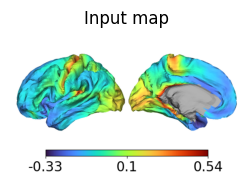

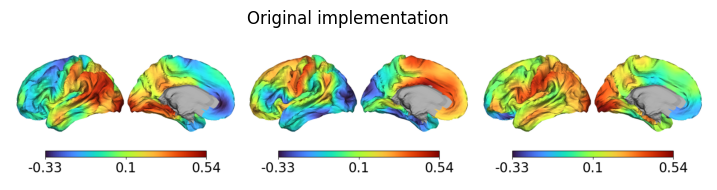

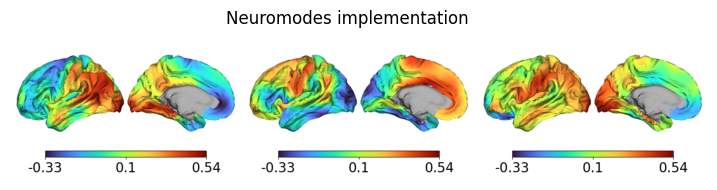

In [7]:
fig1 = plot_surf(
    mesh=mesh_file,
    data=unmask_data(map, medmask),
    cmap='turbo',
    cbar=True
)
plt.title("Input map")

plot_surf(
    mesh=mesh_file,
    data=unmask_data(nulls_orig[:, :3], medmask),
    cmap='turbo',
    cbar=True
)
# plt.suptitle("Neuromodes nulls (non-normalized)")
plt.suptitle("Original implementation")

plot_surf(
    mesh=mesh_file,
    data=unmask_data(nulls_neuromodes[:, :3], medmask),
    cmap='turbo',
    cbar=True
)
# plt.suptitle("Neuromodes nulls (normalized)")
plt.suptitle("Neuromodes implementation")

plt.show()

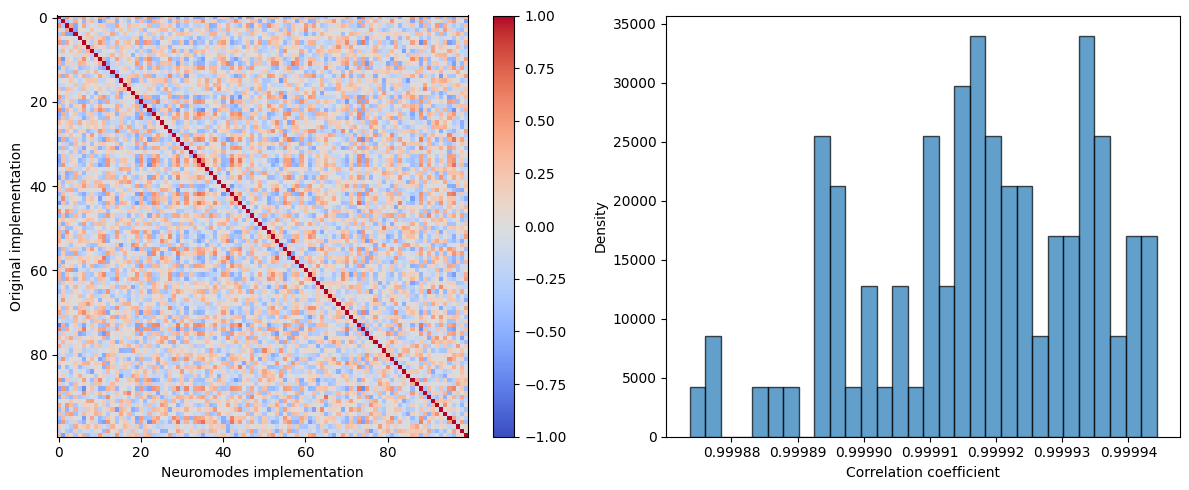

In [8]:
null_corrs = np.corrcoef(nulls_neuromodes.T, nulls_orig.T)[:n_nulls, n_nulls:]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap using matplotlib
im = axs[0].imshow(null_corrs, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
fig.colorbar(im, ax=axs[0])
axs[0].set_xlabel("Neuromodes implementation")
axs[0].set_ylabel("Original implementation")

# Histogram
diagonal_corrs = np.diagonal(null_corrs)
axs[1].hist(diagonal_corrs, bins=30, density=True, alpha=0.7, edgecolor='black')

axs[1].set_xlabel("Correlation coefficient")
axs[1].set_ylabel("Density")
axs[1].locator_params(axis='x', nbins=8)

plt.tight_layout()
plt.show()